### Best Model Analysis and Exploration

This notebook will be used to explore the results of our best preforming model, eploring the residuals and start the preformance of the residual analysis. We'll need to read in all of the data and eventually join back in the `grid_point_id's` to get a better understanding of the impact of missing data on our model etc.

I think here it also is worth it to explore the fuller model and undertstand where the data is missing where we actually see target data above 0 (e.g. there is a proportion damaged) and what % are missing data.

Overall todo's here:
- read in all the needed data
- join the grid_point_id's back in
- Overall look into where the non-filtered data is missing the ntl data or affected 0 where we have target data showing impact
    - what's the pattern we see here, what can we say about these results and how could this be helped?
- 

Import needed libraries:

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, root_mean_squared_error
import seaborn as sns
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import networkx as nx
from itertools import product
import pickle
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', category=DataConversionWarning)
from sklearn.inspection import permutation_importance
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from typing import List
plt.rcParams['font.family'] = 'Helvetica'
%matplotlib inline

%load_ext autoreload
%autoreload 2

from helper_functions import *

BACKGROUND_COLOR = '#EAF2EF'

thesis_cmap_div = mcolors.LinearSegmentedColormap.from_list(
    "thesis_div",
    [
        '#F6511D',  # orange red — negative
        '#EAF2EF',  # off white — zero
        '#097FC7',  # ocean blue — positive
    ]
)

cmap1 = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#0088ce', '#7fb646', '#ee964b', '#87677b', '#26413c']
)

same_scale_color_map = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#D6F1FF', '#33BBFF', '#0088ce', '#005F8F', '#001B29']
)

Read in the data and models:

In [ ]:
# Load model
with open('../models/randomforest_standard.pkl', 'rb') as f:
    model_random_forest = pickle.load(f)
with open('../models/lgbm_tuned.pkl', 'rb') as f:
    model_lgbm = pickle.load(f)

# Load and split data
df_f = pd.read_csv('../data/target/model_training_data_final.csv')
X_train_f, X_test_f, y_train_f, y_test_f = clean_and_split_data(
    df_f, ['percent_houses_damaged_5years', 'percent_houses_damaged'],
    'percent_houses_damaged', filling_method='complex'
)

X_train_wo_grid = X_train_f.drop(columns=['grid_point_id'])
X_test_wo_grid = X_test_f.drop(columns=['grid_point_id'])

# Compute residuals
rf_results_data = X_test_f.copy()
rf_results_data['residuals'] = compute_residuals(model_random_forest, X_test_f, y_test_f)
rf_results_data['y_pred'] = model_random_forest.predict(X_test_f)
rf_results_data['y_actual'] = y_test_f.values

lgbm_results_data = X_test_wo_grid.copy()
lgbm_results_data['residuals'] = compute_residuals(model_lgbm, X_test_wo_grid, y_test_f)
lgbm_results_data['y_pred'] = model_lgbm.predict(X_test_wo_grid)
lgbm_results_data['y_actual'] = y_test_f.values

# Add grid_point_id from X_test_f using shared index
lgbm_results_data['grid_point_id'] = X_test_f['grid_point_id'].values

# Load grid shapefile
gdf = gpd.read_file('../data/shape_files/clipped_grid_for_analysis.gpkg')
gdf.rename(columns={'id': 'grid_point_id'}, inplace=True)

# Merge with geometry\
lgbm_results_data_gdf = gdf.merge(lgbm_results_data, on='grid_point_id', how='right')
rf_results_data_gdf = gdf.merge(rf_results_data,   on='grid_point_id', how='right')

print(f"RF results: {len(rf_results_data_gdf)} rows")
print(f"LGBM results: {len(lgbm_results_data_gdf)} rows")

# random forest — has grid_point_id
rf_train_data = X_train_f.copy()
rf_train_data['residuals'] = compute_residuals(model_random_forest, X_train_f, y_train_f)
rf_train_data['y_pred'] = model_random_forest.predict(X_train_f)
rf_train_data['y_actual'] = y_train_f.values
rf_train_data['split'] = 'train'
rf_results_data['split'] = 'test'

rf_full = pd.concat([rf_train_data, rf_results_data])
rf_full_gdf = gdf.merge(rf_full, on='grid_point_id', how='right')

# lgbm — need to add grid_point_id from X_train_f
lgbm_train_data = X_train_f.drop(columns=['grid_point_id']).copy()
lgbm_train_data['grid_point_id'] = X_train_f['grid_point_id'].values
lgbm_train_data['residuals'] = compute_residuals(model_lgbm, X_train_f.drop(columns=['grid_point_id']), y_train_f)
lgbm_train_data['y_pred'] = model_lgbm.predict(X_train_f.drop(columns=['grid_point_id']))
lgbm_train_data['y_actual'] = y_train_f.values
lgbm_train_data['split'] = 'train'
lgbm_results_data['split'] = 'test'

lgbm_full = pd.concat([lgbm_train_data, lgbm_results_data])
lgbm_full_gdf = gdf.merge(lgbm_full, on='grid_point_id', how='right')

print(f"RF full: {len(rf_full_gdf)} rows")
print(f"LGBM full: {len(lgbm_full_gdf)} rows")

RF results:   8150 rows
LGBM results: 8150 rows
RF full:   32598 rows
LGBM full: 32598 rows


In [28]:
grid_point_avail_across_storm_test =  lgbm_full_gdf.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
grid_point_residuals_across_storm_test =  lgbm_full_gdf.groupby('grid_point_id')['residuals'].mean()
grid_point_ground_truth_across_storm_test =  lgbm_full_gdf.groupby('grid_point_id')['y_actual'].mean()

#rest the column name to make easier to join and reset the index for merging
grid_point_avail_across_storm_test = grid_point_avail_across_storm_test.reset_index()
grid_point_residuals_across_storm_test = grid_point_residuals_across_storm_test.reset_index()
grid_point_ground_truth_across_storm_test = grid_point_ground_truth_across_storm_test.reset_index()

#join the geodata to these median values for plotting
grid_point_avail_across_storm_test_gdf = gdf.merge(grid_point_avail_across_storm_test, on='grid_point_id', how='right')
grid_point_residuals_across_storm_test_gdf = gdf.merge(grid_point_residuals_across_storm_test, on='grid_point_id', how='right')
grid_point_ground_truth_across_storm_test_gdf = gdf.merge(grid_point_ground_truth_across_storm_test, on='grid_point_id', how='right')

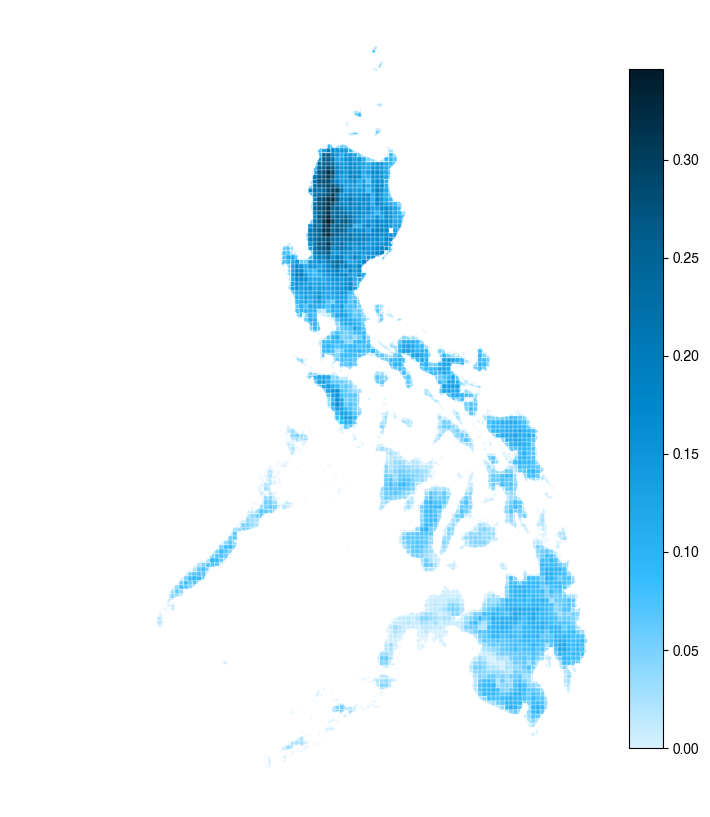

In [46]:
grid_point_avail_across_storm_test_gdf
'perc_available_upscaled_new',
"NTL Availability",
same_scale_color_map,

fig, ax = plot_geodataframe_choropleth(
    grid_point_avail_across_storm_test_gdf,
    column="perc_available_upscaled_new",
    cmap=same_scale_color_map,
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
    # title="Count of Available Observations per Grid Cell with 10% Availability"
)
plt.show()

In [34]:
# was the best 0.01
avail_mask = lgbm_full_gdf.perc_available_upscaled_new >= 0.1

X_avail_gdf = lgbm_full_gdf[avail_mask]

X_cell_counts = X_avail_gdf.groupby('grid_point_id').count()['typhoon_year'].reset_index().rename(columns={'typhoon_year':'count'})
X_cell_counts_gdf = gdf.merge(X_cell_counts, on='grid_point_id', how='left')


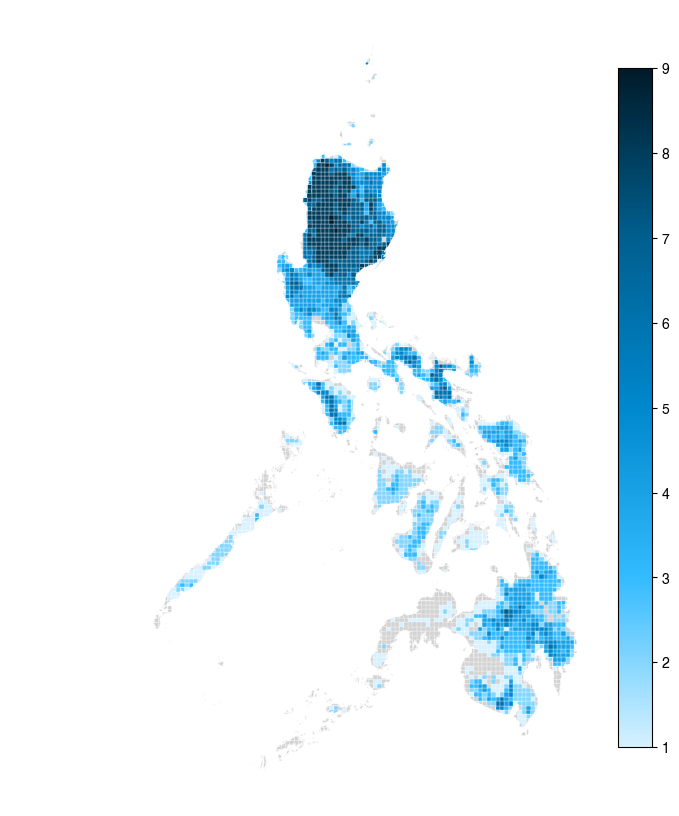

In [48]:
fig, ax = plot_geodataframe_choropleth(
    X_cell_counts_gdf,
    column="count",
    cmap=same_scale_color_map,
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
    # title="Count of Available Observations per Grid Cell with 10%+ Availability"
)
plt.show()

Dropped 12943 rows above 25% missingness threshold
Remaining: 26899 from 39842


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
 

LGBM results: 5673 rows
LGBM full: 22690 rows


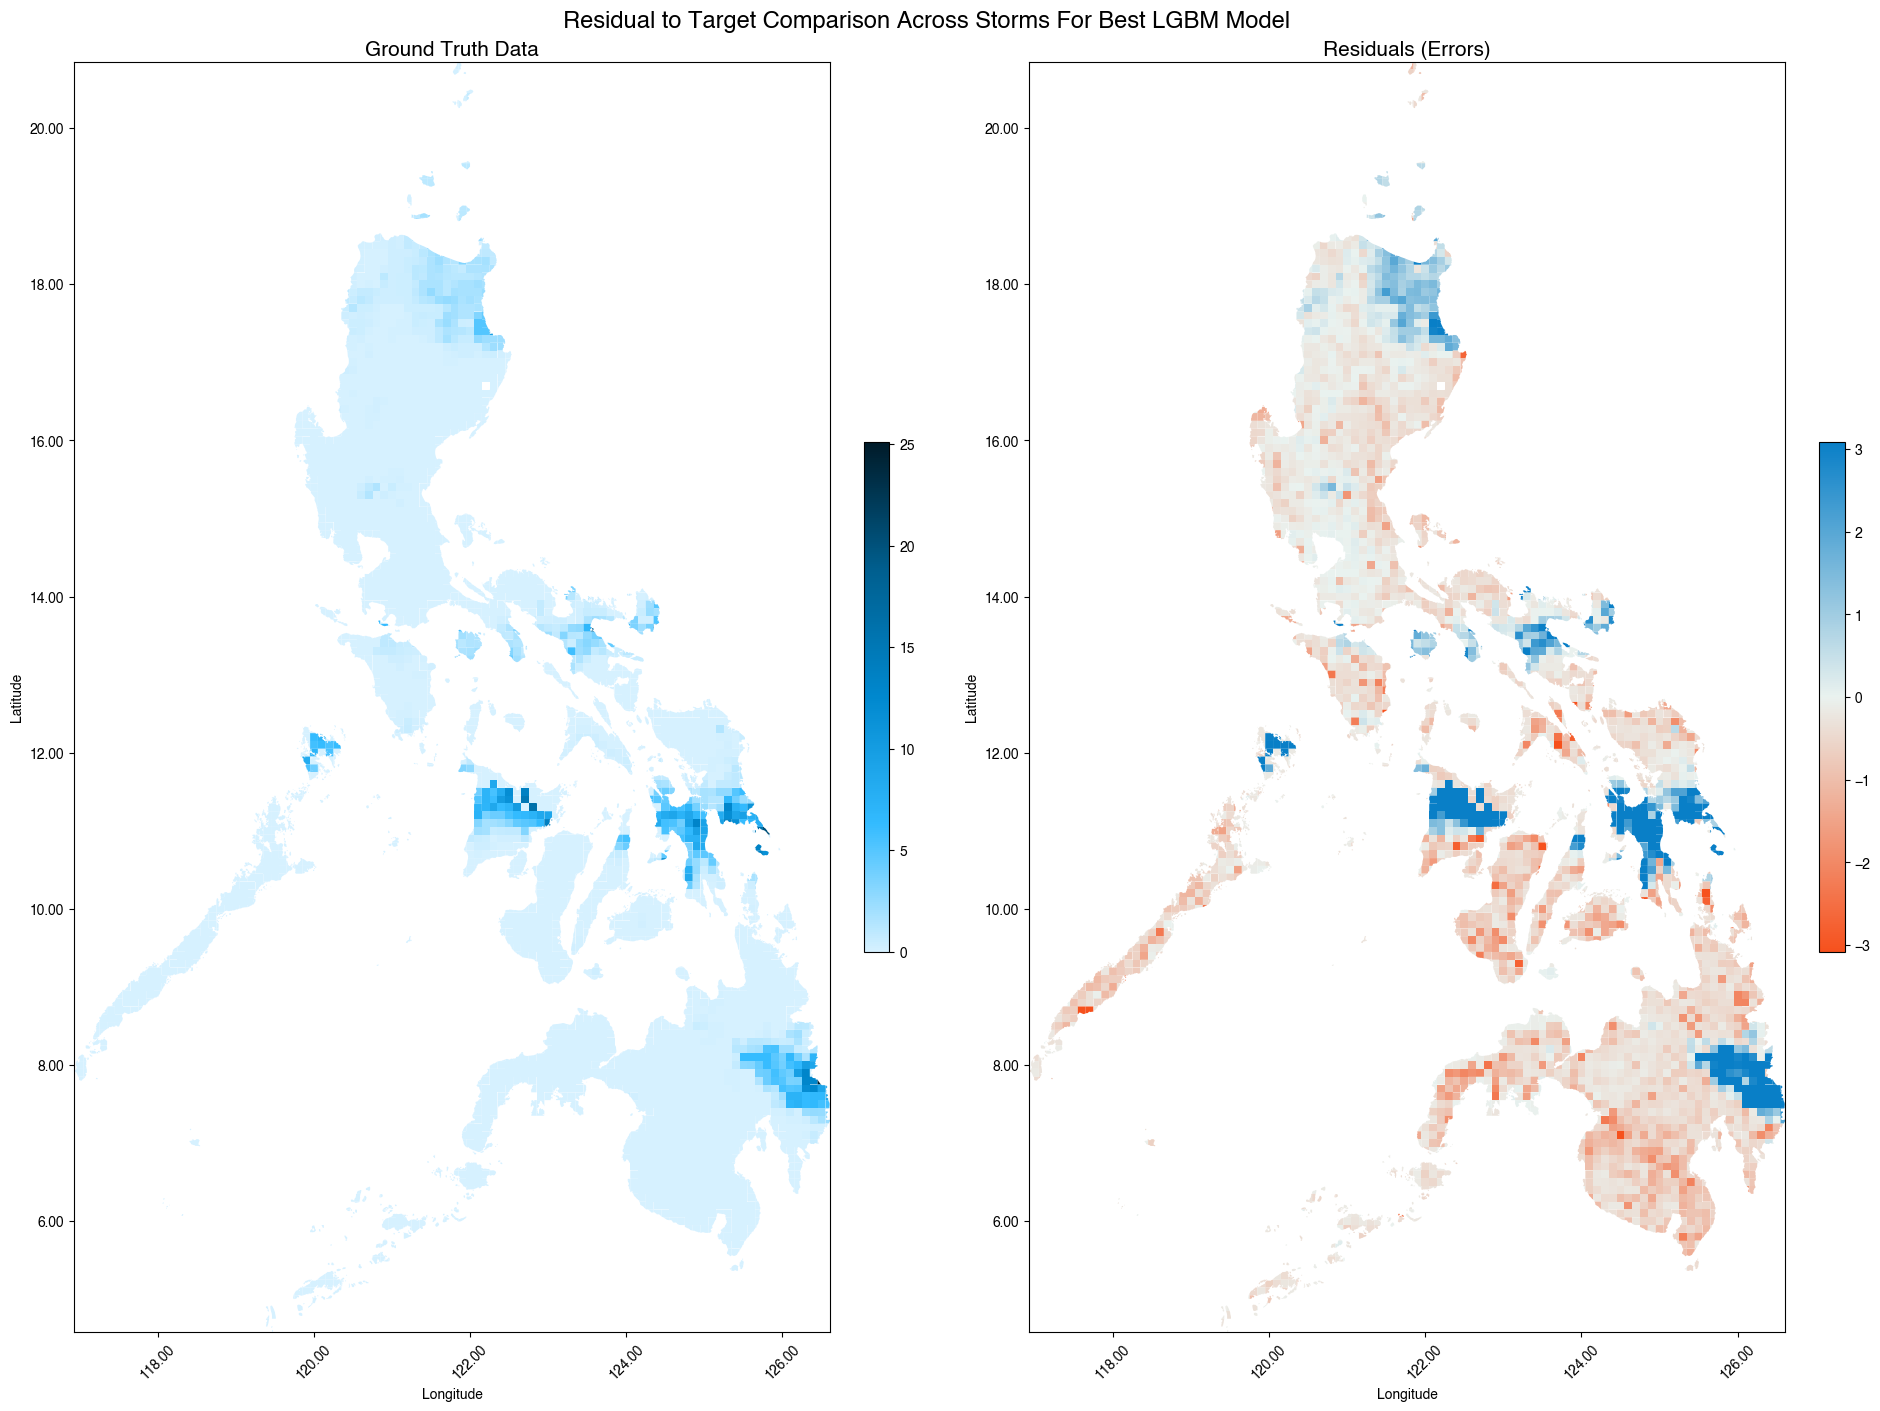

In [ ]:
#load model
with open('../models/lgbm_minmax_dropped.pkl', 'rb') as f:
    model_lgbm = pickle.load(f)

# Load and split data
df_f = pd.read_csv('../data/target/model_training_data_final.csv')
df_cleaned = drop_rows_by_missingness(df_f, 0.25)

X_train_f, X_test_f, y_train_f, y_test_f, typhoon_train_f, typhoon_test_f = clean_and_split_data(
    df_cleaned, ['percent_houses_damaged_5years', 'percent_houses_damaged'],
    'percent_houses_damaged', filling_method='complex',selected_storm="None"
)

X_train_wo_grid = X_train_f.drop(columns=['grid_point_id'])
X_test_wo_grid = X_test_f.drop(columns=['grid_point_id'])

# Compute residuals
lgbm_results_data = X_test_wo_grid.copy()
lgbm_results_data['residuals'] = compute_residuals(model_lgbm, X_test_wo_grid, y_test_f)
lgbm_results_data['y_pred'] = model_lgbm.predict(X_test_wo_grid)
lgbm_results_data['y_actual'] = y_test_f.values

# Add grid_point_id from X_test_f using shared index
lgbm_results_data['grid_point_id'] = X_test_f['grid_point_id'].values

# Load grid shapefile
gdf = gpd.read_file('../data/shape_files/clipped_grid_for_analysis.gpkg')
gdf.rename(columns={'id': 'grid_point_id'}, inplace=True)

# Merge with geometry\
lgbm_results_data_gdf = gdf.merge(lgbm_results_data, on='grid_point_id', how='right')

print(f"LGBM results: {len(lgbm_results_data_gdf)} rows")

# lgbm — need to add grid_point_id from X_train_f
lgbm_train_data = X_train_f.drop(columns=['grid_point_id']).copy()
lgbm_train_data['grid_point_id'] = X_train_f['grid_point_id'].values
lgbm_train_data['residuals'] = compute_residuals(model_lgbm, X_train_f.drop(columns=['grid_point_id']), y_train_f)
lgbm_train_data['y_pred'] = model_lgbm.predict(X_train_f.drop(columns=['grid_point_id']))
lgbm_train_data['y_actual'] = y_train_f.values
lgbm_train_data['split'] = 'train'
lgbm_results_data['split'] = 'test'

lgbm_full = pd.concat([lgbm_train_data, lgbm_results_data])
lgbm_full_gdf = gdf.merge(lgbm_full, on='grid_point_id', how='right')

# print(f"RF full:   {len(rf_full_gdf)} rows")
print(f"LGBM full: {len(lgbm_full_gdf)} rows")

grid_point_avail_across_storm_test =  lgbm_full_gdf.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
grid_point_residuals_across_storm_test =  lgbm_full_gdf.groupby('grid_point_id')['residuals'].mean()
grid_point_ground_truth_across_storm_test =  lgbm_full_gdf.groupby('grid_point_id')['y_actual'].mean()

#rest the column name to make easier to join and reset the index for merging
grid_point_avail_across_storm_test = grid_point_avail_across_storm_test.reset_index()
grid_point_residuals_across_storm_test = grid_point_residuals_across_storm_test.reset_index()
grid_point_ground_truth_across_storm_test = grid_point_ground_truth_across_storm_test.reset_index()

#join the geodata to these median values for plotting
grid_point_avail_across_storm_test_gdf = gdf.merge(grid_point_avail_across_storm_test, on='grid_point_id', how='right')
grid_point_residuals_across_storm_test_gdf = gdf.merge(grid_point_residuals_across_storm_test, on='grid_point_id', how='right')
grid_point_ground_truth_across_storm_test_gdf = gdf.merge(grid_point_ground_truth_across_storm_test, on='grid_point_id', how='right')

fig, axes = plot_choropleth_grid(
    [grid_point_ground_truth_across_storm_test_gdf,grid_point_residuals_across_storm_test_gdf],
    columns=['y_actual','residuals'],
    titles=["Ground Truth Data","Residuals (Errors)",],
    cmaps=[same_scale_color_map,thesis_cmap_div],
    suptitle="Residual to Target Comparison Across Storms For Best LGBM Model",
    missing_color='white',
    shared_scale=False, 
    diverging = [False, True],
    figsize = (19, 14),  # all panels use the same min/max
)
plt.show()


In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

#load model old: lgbm_minmax_dropped.pkl
with open('../models/lgbm_tuned_.pkl', 'rb') as f:
    model_lgbm = pickle.load(f)

# lgbm_tuned_.pk

# Load and split data
df_f = pd.read_csv('../data/target/model_training_data_final.csv')
# df_cleaned = drop_rows_by_missingness(df_f, 0.25)

X_train_f, X_test_f, y_train_f, y_test_f, typhoon_train_f, typhoon_test_f = clean_and_split_data(
    df_f, ['percent_houses_damaged_5years', 'percent_houses_damaged'],
    'percent_houses_damaged', filling_method='complex', selected_storm="None"
)

X_train_wo_grid = X_train_f.drop(columns=['grid_point_id'])
X_test_wo_grid = X_test_f.drop(columns=['grid_point_id'])

# Compute residuals
lgbm_results_data = X_test_wo_grid.copy()
lgbm_results_data['residuals'] = compute_residuals(model_lgbm, X_test_wo_grid, y_test_f)
lgbm_results_data['y_pred'] = model_lgbm.predict(X_test_wo_grid)
lgbm_results_data['y_actual'] = y_test_f.values
# add the storm name back in
lgbm_results_data['typhoon_name'] = typhoon_test_f.values

# Add grid_point_id from X_test_f using shared index
lgbm_results_data['grid_point_id'] = X_test_f['grid_point_id'].values

# Load grid shapefile
gdf = gpd.read_file('../data/shape_files/clipped_grid_for_analysis.gpkg')
gdf.rename(columns={'id': 'grid_point_id'}, inplace=True)

# Merge with geometry\
lgbm_results_data_gdf = gdf.merge(lgbm_results_data, on='grid_point_id', how='right')

print(f"LGBM results: {len(lgbm_results_data_gdf)} rows")

# lgbm — need to add grid_point_id from X_train_f
lgbm_train_data = X_train_f.drop(columns=['grid_point_id']).copy()
lgbm_train_data['grid_point_id'] = X_train_f['grid_point_id'].values
lgbm_train_data['residuals'] = compute_residuals(model_lgbm, X_train_f.drop(columns=['grid_point_id']), y_train_f)
lgbm_train_data['y_pred'] = model_lgbm.predict(X_train_f.drop(columns=['grid_point_id']))
lgbm_train_data['y_actual'] = y_train_f.values
# add storm name back in
lgbm_train_data['typhoon_name'] = typhoon_train_f.values
lgbm_train_data['split'] = 'train'
lgbm_results_data['split'] = 'test'

lgbm_full = pd.concat([lgbm_train_data, lgbm_results_data])
lgbm_full_gdf = gdf.merge(lgbm_full, on='grid_point_id', how='right')

LGBM results: 8150 rows


In [ ]:
grid_point_avail_across_storm_test_gdf_storm['diff_in_avail_from_avg'] = grid_point_avail_across_storm['perc_available_upscaled_new'] - grid_point_avail_across_storm_test_gdf_storm['perc_available_upscaled_new'] 
grid_point_avail_across_storm_test_gdf_storm

,grid_point_id,Longitude,Latitude,Centroid,geometry,perc_available_upscaled_new,diff_in_avail
0,101,114.3,11.1,114.3E_11.1N,"MULTIPOLYGON (((114.27376 11.05, 114.27376 11....",0.000000,0.000000
1,4475,116.9,7.9,116.9E_7.9N,"MULTIPOLYGON (((116.95 7.91394, 116.94995 7.91...",0.007716,-0.006496
2,4639,117.0,8.2,117.0E_8.2N,"MULTIPOLYGON (((117.01008 8.18429, 117.01012 8...",0.000000,0.000000
3,4640,117.0,8.1,117.0E_8.1N,"MULTIPOLYGON (((117.05 8.05, 116.99617 8.05, 1...",0.001484,-0.001092
4,4641,117.0,8.0,117.0E_8.0N,"MULTIPOLYGON (((116.9766 8.05, 116.97665 8.049...",0.019009,-0.004612
...,...,...,...,...,...,...,...
3617,20677,126.6,7.6,126.6E_7.6N,"MULTIPOLYGON (((126.56128 7.65, 126.56128 7.64...",0.010667,0.006122
3618,20678,126.6,7.5,126.6E_7.5N,"MULTIPOLYGON (((126.5885 7.55, 126.58851 7.549...",0.001792,0.039854
3619,20679,126.6,7.4,126.6E_7.4N,"MULTIPOLYGON (((126.60003 7.45, 126.59995 7.44...",0.006098,0.005735
3620,20680,126.6,7.3,126.6E_7.3N,"MULTIPOLYGON (((126.56148 7.35, 126.56156 7.34...",0.016428,0.000884


In [81]:
grid_point_avail_across_storm_test_storm['perc_available_upscaled_new'].corr(grid_point_predictions_across_storm_test_storm['y_pred'])

np.float64(-0.33808867581569413)

In [82]:
# method='spearman'

grid_point_avail_across_storm_test_storm['perc_available_upscaled_new'].corr(grid_point_predictions_across_storm_test_storm['y_pred'],method='spearman')

np.float64(-0.49616506161834223)

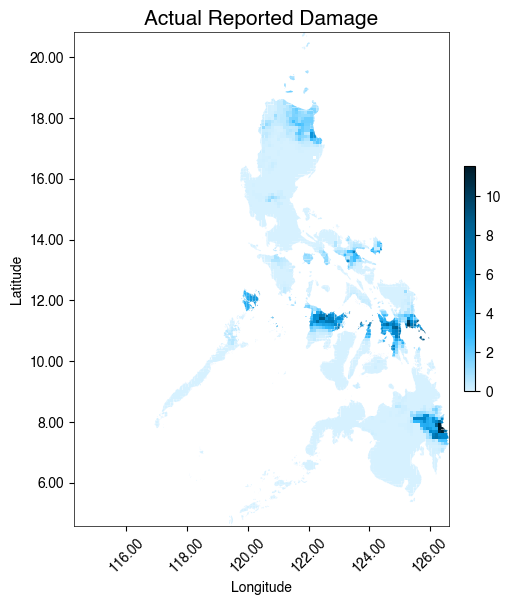

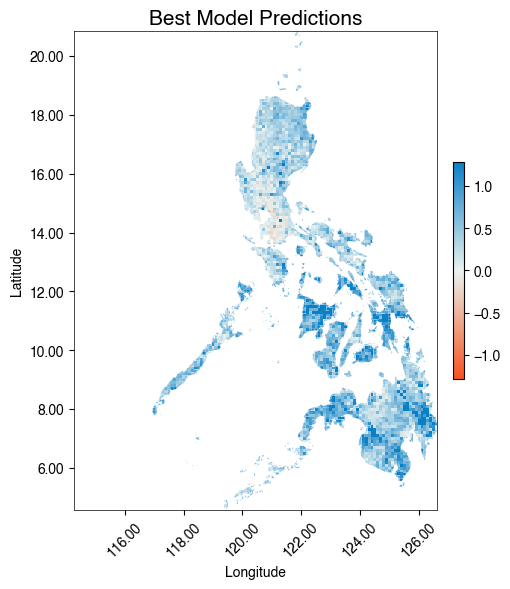

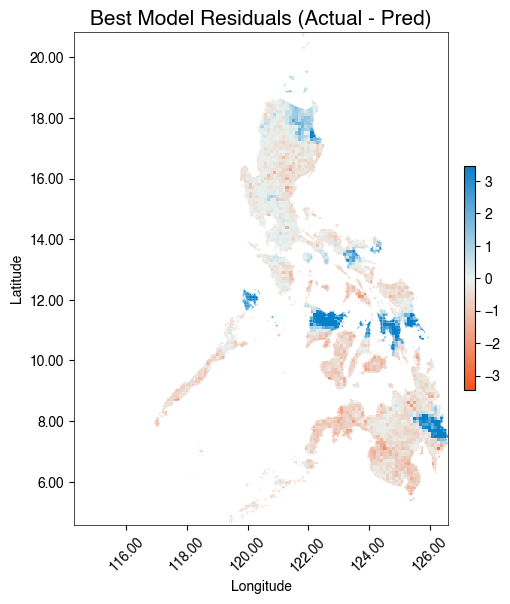

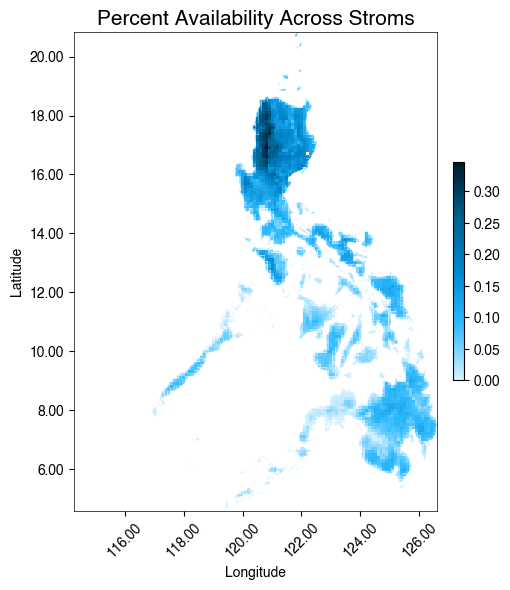

In [ ]:
# lgbm_full_gdf

grid_point_avail_across_storm_test_storm =  lgbm_full_gdf.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
grid_point_residuals_across_storm_test_storm =  lgbm_full_gdf.groupby('grid_point_id')['residuals'].mean()
grid_point_ground_truth_across_storm_test_storm =  lgbm_full_gdf.groupby('grid_point_id')['y_actual'].mean()
grid_point_predictions_across_storm_test_storm =  lgbm_full_gdf.groupby('grid_point_id')['y_pred'].mean()

#rest the column name to make easier to join and reset the index for merging
grid_point_avail_across_storm_test_storm = grid_point_avail_across_storm_test_storm.reset_index()
grid_point_residuals_across_storm_test_storm = grid_point_residuals_across_storm_test_storm.reset_index()
grid_point_ground_truth_across_storm_test_storm = grid_point_ground_truth_across_storm_test_storm.reset_index()
grid_point_predictions_across_storm_test_storm =  grid_point_predictions_across_storm_test_storm.reset_index()

#join the geodata to these median values for plotting
grid_point_avail_across_storm_test_gdf_storm = gdf.merge(grid_point_avail_across_storm_test_storm, on='grid_point_id', how='right')
grid_point_residuals_across_storm_test_gdf_storm = gdf.merge(grid_point_residuals_across_storm_test_storm, on='grid_point_id', how='right')
grid_point_ground_truth_across_storm_test_gdf_storm = gdf.merge(grid_point_ground_truth_across_storm_test_storm, on='grid_point_id', how='right')
grid_point_predictions_across_storm_test_gdf_storm = gdf.merge(grid_point_predictions_across_storm_test_storm, on='grid_point_id', how='right')
#     print(storm)
#     print(grid_point_residuals_across_storm_test_storm.residuals.max(),
#           grid_point_residuals_across_storm_test_storm.residuals.min())

#     print(grid_point_ground_truth_across_storm_test_storm.y_actual.max(),
#           grid_point_ground_truth_across_storm_test_storm.y_actual.min())

try:
    fig, axes = plot_geodataframe_choropleth(
                grid_point_ground_truth_across_storm_test_gdf_storm,
                'y_actual',
                same_scale_color_map,
                (5,9),
                'Actual Reported Damage',
                # vmin: float = None,
                # vmax: float = None,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=False
            )
    figure_name = f"ground_truth_overall.jpeg"
    plt.savefig(f'../figures/figures_for_results/{figure_name}')
    plt.show()

    fig, axes = plot_geodataframe_choropleth(
                grid_point_predictions_across_storm_test_gdf_storm,
                'y_pred',
                thesis_cmap_div,
                (5,9),
                'Best Model Predictions',
                # vmin: float = None,
                # vmax: float = None,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=True
            )
    figure_name = f"y_pred_overall.jpeg"
    plt.savefig(f'../figures/figures_for_results/{figure_name}')
    plt.show()

    fig, axes = plot_geodataframe_choropleth(
                grid_point_residuals_across_storm_test_gdf_storm,
                'residuals',
                thesis_cmap_div,
                (5,9),
                'Best Model Residuals (Actual - Pred)',
                # vmin: float = None,
                # vmax: float = None,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=True
            )
    figure_name = f"residuals_overall.jpeg"
    plt.savefig(f'../figures/figures_for_results/{figure_name}')
    plt.show()

    fig, axes = plot_geodataframe_choropleth(
                grid_point_avail_across_storm_test_gdf_storm,
                'perc_available_upscaled_new',
                same_scale_color_map,
                (5,9),
                'Percent Availability Across Stroms',
                # vmin: float = None,
                # vmax: float = None,
                # edge_color: str = "none",
                # edge_width: float = 0.1,
                missing_color="white",
                diverging=False
            )
    figure_name = f"availability_overall.jpeg"
    plt.savefig(f'../figures/figures_for_results/{figure_name}')
    plt.show()
except Exception as e:
    print(f"Skipping {storm}: {e}") 
finally:
    pass

In [ ]:
storm_names_simp = [
    'bopha',
    'trami',
    'usagi',
    'nari',
    'krosa',
    'haiyan',
    'lingling',
    'sarika',
    'haima',
    'nock-ten',
    'mangkhut'
] # TRAMI

grid_point_avail_across_storm =  lgbm_full_gdf.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
# #rest the column name to make easier to join and reset the index for merging
# grid_point_avail_across_storm = grid_point_avail_across_storm.reset_index()

# #join the geodata to these median values for plotting
# grid_point_avail_across_storm = gdf.merge(grid_point_avail_across_storm, on='grid_point_id', how='right')

for storm in storm_names_simp:
    storm = storm.upper()
    lgbm_full_gdf_storm = lgbm_full_gdf[lgbm_full_gdf['typhoon_name']==storm]
    grid_point_avail_across_storm_test_storm =  lgbm_full_gdf_storm.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
    grid_point_residuals_across_storm_test_storm =  lgbm_full_gdf_storm.groupby('grid_point_id')['residuals'].mean()
    grid_point_ground_truth_across_storm_test_storm =  lgbm_full_gdf_storm.groupby('grid_point_id')['y_actual'].mean()
    grid_point_predictions_across_storm_test_storm =  lgbm_full_gdf_storm.groupby('grid_point_id')['y_pred'].mean()
    grid_point_diff_in_avail_across_storm_test_gdf_storm = grid_point_avail_across_storm - grid_point_avail_across_storm_test_storm

    # rest the column name to make easier to join and reset the index for merging
    grid_point_avail_across_storm_test_storm = grid_point_avail_across_storm_test_storm.reset_index()
    grid_point_residuals_across_storm_test_storm = grid_point_residuals_across_storm_test_storm.reset_index()
    grid_point_ground_truth_across_storm_test_storm = grid_point_ground_truth_across_storm_test_storm.reset_index()
    grid_point_predictions_across_storm_test_storm =  grid_point_predictions_across_storm_test_storm.reset_index()

    #join the geodata to these median values for plotting
    grid_point_avail_across_storm_test_gdf_storm = gdf.merge(grid_point_avail_across_storm_test_storm, on='grid_point_id', how='right')
    grid_point_residuals_across_storm_test_gdf_storm = gdf.merge(grid_point_residuals_across_storm_test_storm, on='grid_point_id', how='right')
    grid_point_ground_truth_across_storm_test_gdf_storm = gdf.merge(grid_point_ground_truth_across_storm_test_storm, on='grid_point_id', how='right')
    grid_point_predictions_across_storm_test_gdf_storm = gdf.merge(grid_point_predictions_across_storm_test_storm, on='grid_point_id', how='right')

    # grid_point_avail_across_storm_test_gdf_storm['diff_in_avail_from_avg'] = grid_point_avail_across_storm['perc_available_upscaled_new'] - grid_point_avail_across_storm_test_gdf_storm['perc_available_upscaled_new']
#     print(storm)
#     print(grid_point_residuals_across_storm_test_storm.residuals.max(),
#           grid_point_residuals_across_storm_test_storm.residuals.min())
    
#     print(grid_point_ground_truth_across_storm_test_storm.y_actual.max(),
#           grid_point_ground_truth_across_storm_test_storm.y_actual.min())
    # if storm == "LINGLING":
    print(storm)
    # print(grid_point_predictions_across_storm_test_storm.max()/grid_point_ground_truth_across_storm_test_storm.max())
    # print('preds: ',grid_point_predictions_across_storm_test_storm.max(),'ground-truth: ',grid_point_ground_truth_across_storm_test_storm.max())
    print(grid_point_predictions_across_storm_test_storm['y_pred'].min(),grid_point_predictions_across_storm_test_storm['y_pred'].max())
    # print(grid_point_residuals_across_storm_test_gdf_storm['residuals'].min(),grid_point_residuals_across_storm_test_gdf_storm['residuals'].max())
    # print(grid_point_ground_truth_across_storm_test_storm['y_actual'].min(),grid_point_ground_truth_across_storm_test_storm['y_actual'].max())
    # print(grid_point_diff_in_avail_across_storm_test_gdf_storm.corr(grid_point_predictions_across_storm_test_storm))
    # print(grid_point_diff_in_avail_across_storm_test_gdf_storm.corr(grid_point_predictions_across_storm_test_storm,method='spearman'))

    # try:
    #     fig, axes = plot_geodataframe_choropleth(
    #                 grid_point_ground_truth_across_storm_test_gdf_storm,
    #                 'y_actual',
    #                 same_scale_color_map,
    #                 (5,9),
    #                 'Actual Reported Damage',
    #                 # vmin: float = None,
    #                 # vmax: float = None,
    #                 # edge_color: str = "none",
    #                 # edge_width: float = 0.1,
    #                 missing_color="white",
    #                 diverging=False
    #             )
    #     figure_name = f"ground_truth_{storm}.jpeg"
    #     plt.savefig(f'../figures/figures_for_results/{figure_name}')
    #     plt.show()

        

    #     fig, axes = plot_geodataframe_choropleth(
    #                 grid_point_avail_across_storm_test_gdf_storm,
    #                 'diff_in_avail_from_avg',
    #                 thesis_cmap_div,
    #                 (5,9),
    #                 'Difference in Availability vs. Average',
    #                 # vmin: float = None,
    #                 # vmax: float = None,
    #                 # edge_color: str = "none",
    #                 # edge_width: float = 0.1,
    #                 missing_color="white",
    #                 diverging = True,
    #             )
    #     figure_name = f"diff_in_avail_from_avg_{storm}.jpeg"
    #     plt.savefig(f'../figures/figures_for_results/{figure_name}')
    #     plt.show()

    #     fig, axes = plot_geodataframe_choropleth(
    #                 grid_point_predictions_across_storm_test_gdf_storm,
    #                 'y_pred',
    #                 thesis_cmap_div,
    #                 (5,9),
    #                 'Best Model Predictions',
    #                 # vmin: float = None,
    #                 # vmax: float = None,
    #                 # edge_color: str = "none",
    #                 # edge_width: float = 0.1,
    #                 missing_color="white",
    #                 diverging=True
    #             )
    #     figure_name = f"y_pred_{storm}.jpeg"
    #     plt.savefig(f'../figures/figures_for_results/{figure_name}')
    #     plt.show()

    #     fig, axes = plot_geodataframe_choropleth(
    #                 grid_point_residuals_across_storm_test_gdf_storm,
    #                 'residuals',
    #                 thesis_cmap_div,
    #                 (5,9),
    #                 'Best Model Residuals (Actual - Pred)',
    #                 # vmin: float = None,
    #                 # vmax: float = None,
    #                 # edge_color: str = "none",
    #                 # edge_width: float = 0.1,
    #                 missing_color="white",
    #                 diverging=True
    #             )
    #     figure_name = f"residuals_{storm}.jpeg"
    #     plt.savefig(f'../figures/figures_for_results/{figure_name}')
    #     plt.show()
    # except Exception as e:
    #     print(f"Skipping {storm}: {e}") 
    # finally:
    #     pass


    # plot_geodataframe_choropleth(
    # gdf: gpd.GeoDataFrame,
    # column: str,
    # cmap: str = "viridis",
    # figsize: tuple = None,
    # title: str = None,
    # vmin: float = None,
    # vmax: float = None,
    # edge_color: str = "none",
    # edge_width: float = 0.1,
    # missing_color: str = "lightgrey",
# )

    # try:
    #     fig, axes = plot_choropleth_grid(
    #         [grid_point_ground_truth_across_storm_test_gdf_storm,grid_point_residuals_across_storm_test_gdf_storm,grid_point_predictions_across_storm_test_gdf_storm,grid_point_avail_across_storm_test_gdf_storm],
    #         columns=['y_actual','residuals','y_pred','diff_in_avail_from_avg'],
    #         titles=['Actuals','Residuals (Errors)','Predictions','Availability'],
    #         cmaps=[same_scale_color_map,thesis_cmap_div,thesis_cmap_div,thesis_cmap_div],
    #         suptitle=f"Residual to Target Comparison for {storm.title()} For Best LGBM Model",
    #         missing_color='white',
    #         shared_scale=False, 
    #         diverging = [False,True,True,True],
    #         figsize = (19, 5),  # all panels use the same min/max
    #     )
    #     figure_name = f"residuals_vs_ground_truth_{storm}.jpeg"
    #   #   plt.savefig(f'../figures/{figure_name}')
    #     plt.show()
    # except Exception as e:
    #     print(f"Skipping {storm}: {e}") 
    # finally:
    #     pass


BOPHA
-3.0867029883985175 36.610572901616194
TRAMI
nan nan
USAGI
-0.9240127416676318 2.584021431573215
NARI
-2.155349139637622 7.8456688100621
KROSA
-4.031748675600157 5.426773647856187
HAIYAN
-1.3703863668676335 45.907845693827596
LINGLING
-1.145789466975351 3.269880944659449
SARIKA
nan nan
HAIMA
-1.3879946745197302 6.466607810396194
NOCK-TEN
-1.1112624471494579 7.795482285256848
MANGKHUT
-1.2811976115438322 11.629273675609134


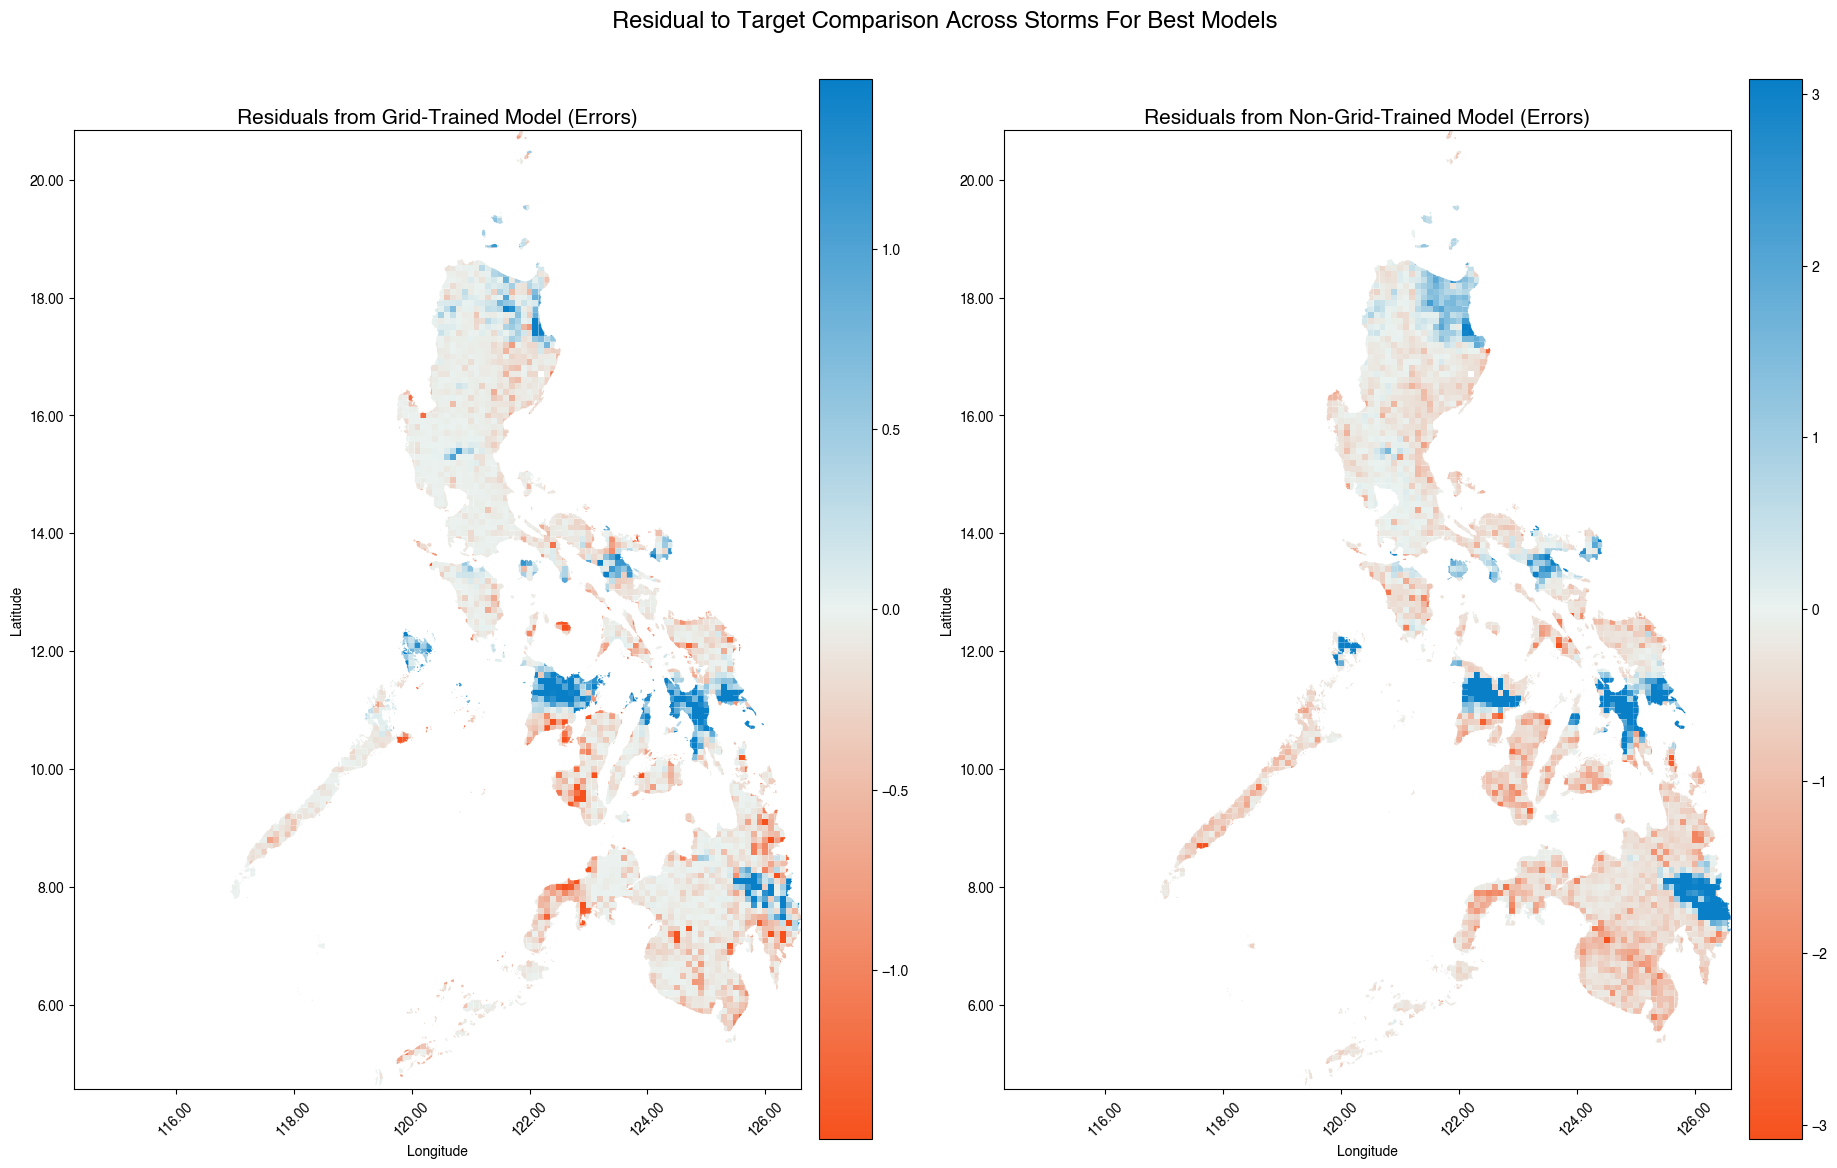

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

# model_random_forest

# Load and split data
df_f = pd.read_csv('../data/target/model_training_data_final.csv')
X_train_f, X_test_f, y_train_f, y_test_f = clean_and_split_data(
    df_f, ['percent_houses_damaged_5years', 'percent_houses_damaged'],
    'percent_houses_damaged', filling_method='complex'
)


# Load grid shapefile
gdf = gpd.read_file('../data/shape_files/clipped_grid_for_analysis.gpkg')
gdf.rename(columns={'id': 'grid_point_id'}, inplace=True)

# Merge with geometry\
rf_results_data_gdf = gdf.merge(rf_results_data,   on='grid_point_id', how='right')

print(f"RF results: {len(rf_results_data_gdf)} rows")
print(f"LGBM results: {len(lgbm_results_data_gdf)} rows")

# random forest — has grid_point_id
rf_train_data = X_train_f.copy()
rf_train_data['residuals'] = compute_residuals(model_random_forest, X_train_f, y_train_f)
rf_train_data['y_pred'] = model_random_forest.predict(X_train_f)
rf_train_data['y_actual'] = y_train_f.values
rf_train_data['split'] = 'train'
rf_results_data['split'] = 'test'

rf_full = pd.concat([rf_train_data, rf_results_data])
rf_full_gdf = gdf.merge(rf_full, on='grid_point_id', how='right')

grid_point_avail_across_storm_test_rf =  rf_full_gdf.groupby('grid_point_id')['perc_available_upscaled_new'].mean()
grid_point_residuals_across_storm_test_rf =  rf_full_gdf.groupby('grid_point_id')['residuals'].mean()
grid_point_ground_truth_across_storm_test_rf =  rf_full_gdf.groupby('grid_point_id')['y_actual'].mean()
grid_point_predictions_across_storm_test_rf =  rf_full_gdf.groupby('grid_point_id')['y_pred'].mean()

#rest the column name to make easier to join and reset the index for merging
grid_point_avail_across_storm_test_rf = grid_point_avail_across_storm_test_rf.reset_index()
grid_point_residuals_across_storm_test_rf = grid_point_residuals_across_storm_test_rf.reset_index()
grid_point_ground_truth_across_storm_test_rf = grid_point_ground_truth_across_storm_test_rf.reset_index()
grid_point_predictions_across_storm_test_rf = grid_point_predictions_across_storm_test_rf.reset_index()

#join the geodata to these median values for plotting
grid_point_avail_across_storm_test_gdf_rf = gdf.merge(grid_point_avail_across_storm_test_rf, on='grid_point_id', how='right')
grid_point_residuals_across_storm_test_gdf_rf = gdf.merge(grid_point_residuals_across_storm_test_rf, on='grid_point_id', how='right')
grid_point_ground_truth_across_storm_test_gdf_rf = gdf.merge(grid_point_ground_truth_across_storm_test_rf, on='grid_point_id', how='right')
grid_point_predictions_across_storm_test_gdf_rf = gdf.merge(grid_point_predictions_across_storm_test_rf, on='grid_point_id', how='right')



fig, axes = plot_choropleth_grid(
    [grid_point_residuals_across_storm_test_gdf_rf,grid_point_residuals_across_storm_test_gdf],
    columns=['residuals','residuals'],
    titles=["Residuals from Grid-Trained Model (Errors)", "Residuals from Non-Grid-Trained Model (Errors)"],
    cmaps=[thesis_cmap_div, thesis_cmap_div],
    suptitle="Residual to Target Comparison Across Storms For Best Models",
    missing_color='white',
    shared_scale=False, 
    diverging = [True, True],
    figsize = (19, 14),  # all panels use the same min/max
)

plt.show()


